## Install dependencies

In [1]:
!pip install tensorflow=='2.15' opencv-python=="4.8.0.74" opencv-contrib-python=="4.5.5.64" gdown --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 475.2/475.2 MB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.7/61.7 MB 11.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.7/66.7 MB 7.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 14.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.0/1.0 MB 11.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 13.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.0/442.0 kB 9.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 77.9/77.9 kB 7.1 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
tensorstore 0.1.68 requires ml-dtypes>=0.3.1, but you have ml-dtypes 0.2.0 which is incompatible.
tf-keras 2.17.0 requires tensorflow<2.18,>=2.17, but you have tensorflow 2.15.0 which is incompatible

## Clone Repository

In [2]:
!git clone https://github.com/ArmandoMGM/phd_fas_uncertainty

Cloning into 'phd_fas_uncertainty'...
remote: Enumerating objects: 7, done.
remote: Counting objects: 100% (7/7), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 7 (delta 1), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (7/7), 5.82 KiB | 5.82 MiB/s, done.
Resolving deltas: 100% (1/1), done.


## Import libraries

In [3]:
from google.colab import drive
drive.mount('/content/gdrive/')

Mounted at /content/gdrive/


In [5]:
from phd_fas_uncertainty.fasuncertainty.pipeline import Pipeline_FAS

In [9]:
from matplotlib import pyplot as plt
import cv2
import glob

## Prepare pipeline

In [7]:
fas_pipeline = Pipeline_FAS()

Face Detection Module...
Loaded Face Detector Model successfully
File 'lbfmodel.yaml' does not exist. Downloading file from original repository...
File downloaded successfully to: /content/phd_fas_uncertainty/models/lbfmodel.yaml
Loaded Landmark Model successfully
Image Quality Assesment Module...
Loaded IQD Classifier Model successfully
Face Anti-Spoofing Module...
Loaded Face Anti-Spoofing Model successfully


## Load images to evaluate

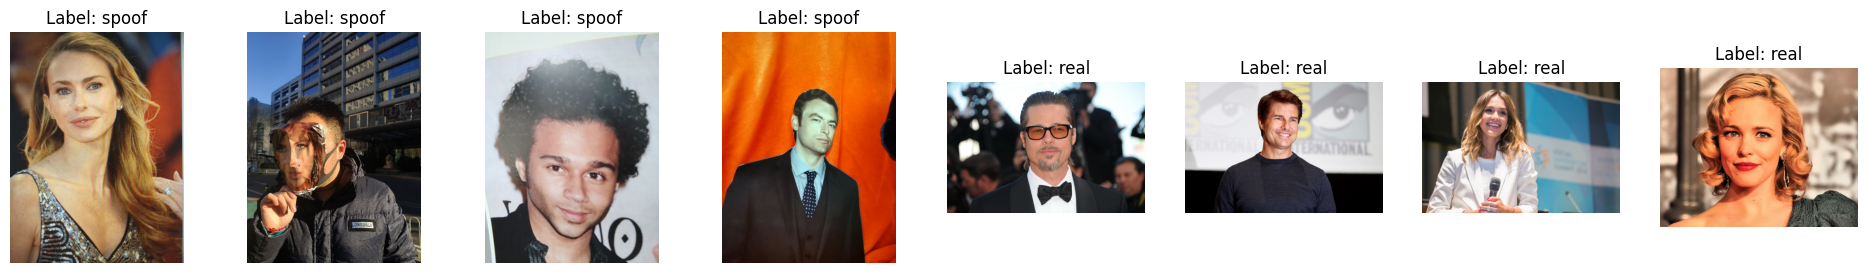

In [42]:
img_paths = glob.glob('/content/phd_fas_uncertainty/image_samples/**/*.*')
images_labels = [(cv2.cvtColor(cv2.imread(img_path), cv2.COLOR_BGR2RGB),
                  img_path.split('/')[-2]) for img_path in img_paths]

num_images = len(images_labels)
fig, axes = plt.subplots(1, num_images, figsize=(min(3*num_images, 40), 3))
for i, (img, label) in enumerate(images_labels):
    axes[i].imshow(img)
    axes[i].title.set_text(f"Label: {label}")
    axes[i].axis('off')

plt.show()

## Predict

In [43]:
images_croped_predicts = []
for i, (img, label) in enumerate(images_labels):

    results = fas_pipeline.predict(img)

    if results[-1]!='indeterminate':
        images_croped_predicts.append((results[0][0], label, results[-1]))
    else:
        images_croped_predicts.append((img, label, results[-1]))

    print(f"""
        SYSTEM OUTPUTS for image {i + 1}, Label: {label}
        --------------
        Face Coordenates:     {results[1]}
        IQD Classifier Model: {results[2]}
        FAS Classifier Model: {results[3]}
        Final Decision:       {results[4]}
        """)



100%|██████████| 25/25 [00:02<00:00,  9.04it/s]



        SYSTEM OUTPUTS for image 1, Label: spoof
        --------------
        Face Coordenates:     [[72, 38, 326, 303], [55, 471, 178, 602]]
        IQD Classifier Model: ('original', 0.99968886)
        FAS Classifier Model: ('real', 0.08681262, 0.056733232)
        Final Decision:       spoof
        


100%|██████████| 25/25 [00:02<00:00,  8.71it/s]



        SYSTEM OUTPUTS for image 2, Label: spoof
        --------------
        Face Coordenates:     [[59, 230, 187, 394]]
        IQD Classifier Model: ('original', 0.99999833)
        FAS Classifier Model: ('real', 0.00014449697, 0.000556411)
        Final Decision:       spoof
        


100%|██████████| 25/25 [00:03<00:00,  7.44it/s]


...


        SYSTEM OUTPUTS for image 6, Label: real
        --------------
        Face Coordenates:     [[397, 86, 597, 347]]
        IQD Classifier Model: ('original', 0.9806771)
        FAS Classifier Model: ('real', 0.99999976, 3.3717478e-07)
        Final Decision:       real
        


100%|██████████| 25/25 [00:03<00:00,  6.75it/s]



        SYSTEM OUTPUTS for image 7, Label: real
        --------------
        Face Coordenates:     [[496, 81, 814, 506], [350, 507, 496, 672], [106, 831, 319, 1031]]
        IQD Classifier Model: ('original', 0.9998517)
        FAS Classifier Model: ('real', 0.9999986, 2.1916685e-06)
        Final Decision:       real
        


100%|██████████| 25/25 [00:02<00:00,  9.11it/s]


        SYSTEM OUTPUTS for image 8, Label: real
        --------------
        Face Coordenates:     [[208, 109, 539, 485]]
        IQD Classifier Model: ('original', 0.9195214)
        FAS Classifier Model: ('real', 0.54097545, 0.19598895)
        Final Decision:       spoof
        


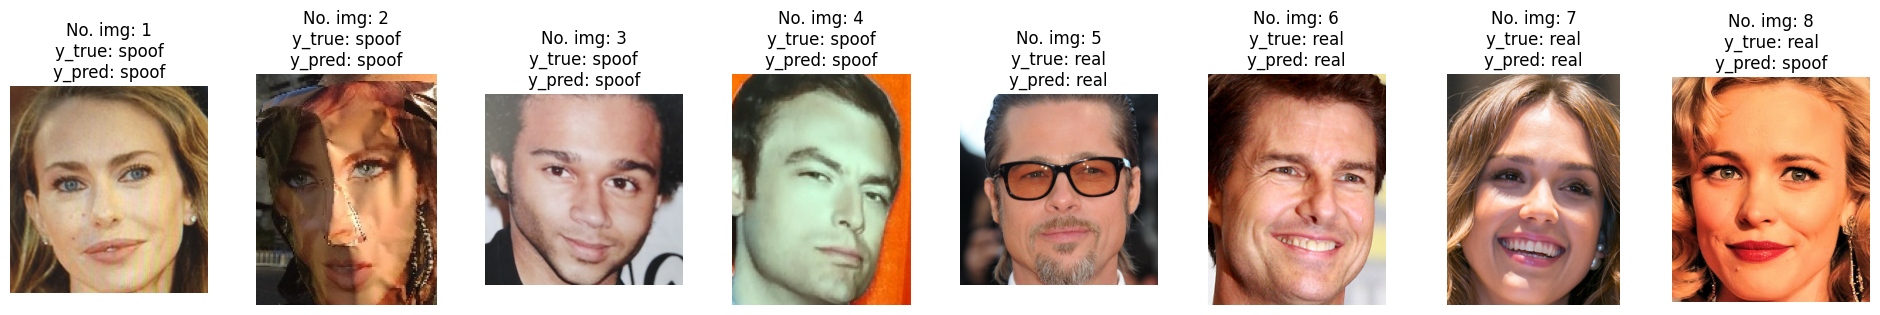

In [45]:
fig, axes = plt.subplots(1, num_images, figsize=(min(3*num_images, 40), 3))
for i, (img, label, predict) in enumerate(images_croped_predicts):
    axes[i].imshow(img)
    axes[i].title.set_text(f"No. img: {i+1}\ny_true: {label}\ny_pred: {predict}")
    axes[i].axis('off')

In [47]:
%%timeit
fas_pipeline.predict(img)
# run with T4 GPU --> 3.18 s ± 280 ms

100%|██████████| 25/25 [00:02<00:00,  9.06it/s]

3.18 s ± 280 ms per loop (mean ± std. dev. of 7 runs, 1 loop each)


END